# Transactional Fraud Detection Analysis

## Week 2: Deep Dive with Exploratory Data Analysis (EDA)

### Objective

To explore transaction patterns and identify factors associated with fraudulent transactions.

### Analysis Areas

- Fraud vs Non-Fraud transactions
- Transaction type
- Transaction amount
- Customer balance
- Destination balance
- Fraud patterns

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("Synthetic_Financial_Datasets_log.csv")


In [4]:
df.shape

(6362620, 11)

In [5]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

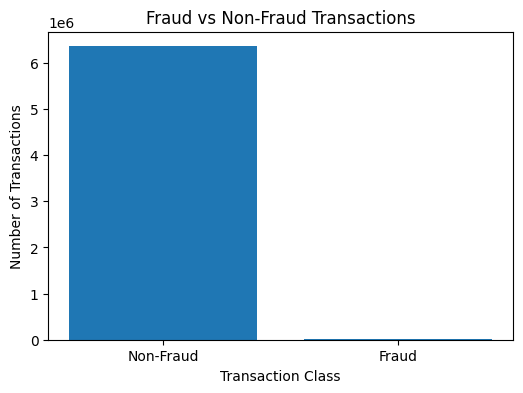

In [6]:
fraud_counts = df["isFraud"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Non-Fraud", "Fraud"], fraud_counts.values)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.show()

##Fraud transactions are much fewer than non-fraud transactions, confirming that the dataset is highly imbalanced.

In [7]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

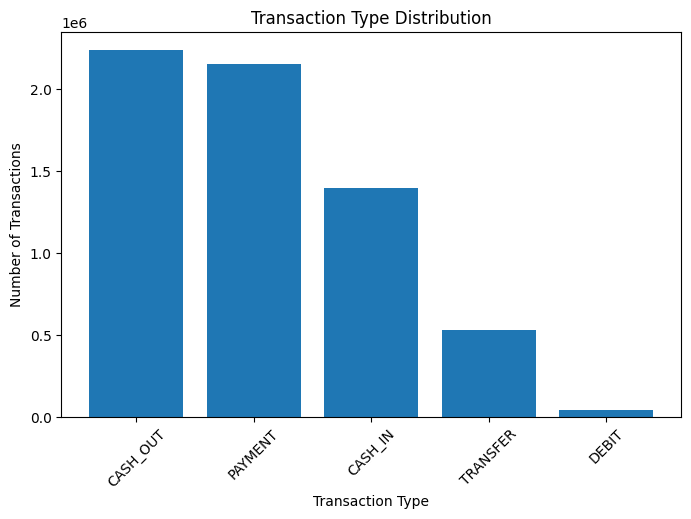

In [8]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(type_counts.index, type_counts.values)
plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

In [9]:
fraud_by_type = df.groupby("type")["isFraud"].sum()

fraud_by_type

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

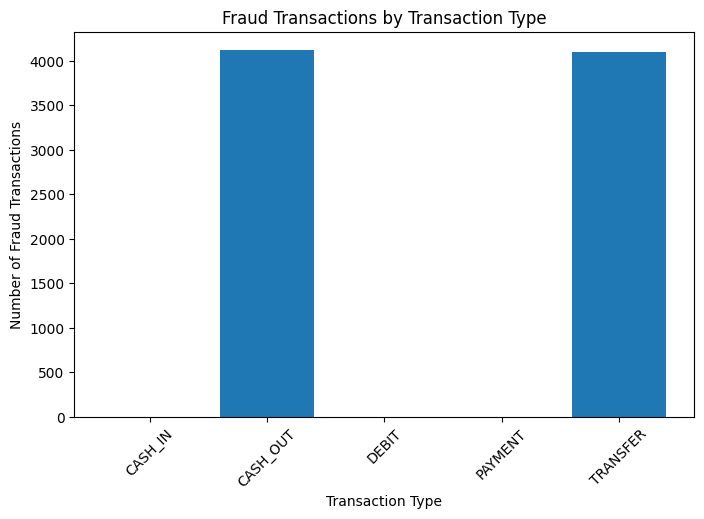

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(fraud_by_type.index, fraud_by_type.values)
plt.title("Fraud Transactions by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Fraud Transactions")
plt.xticks(rotation=45)
plt.show()

In [11]:
df.groupby("isFraud")["amount"].mean()

isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float64

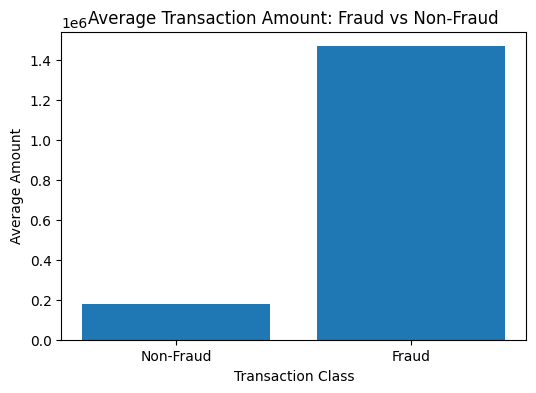

In [12]:
avg_amount = df.groupby("isFraud")["amount"].mean()

plt.figure(figsize=(6, 4))
plt.bar(["Non-Fraud", "Fraud"], avg_amount.values)
plt.title("Average Transaction Amount: Fraud vs Non-Fraud")
plt.xlabel("Transaction Class")
plt.ylabel("Average Amount")
plt.show()

#Fraudulent transactions have a much higher average transaction amount than non-fraudulent transactions in this dataset.

In [13]:
fraud_df = df[df["isFraud"] == 1]

fraud_df["amount"].describe()

count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64

In [ ]:
#Fraud transactions: 8,213
Average amount: ≈ 1,467,967
Median amount: ≈ 441,423
Minimum: 0
Maximum: 10,000,000
75% of fraud amounts: ≈ 1,517,771 is less

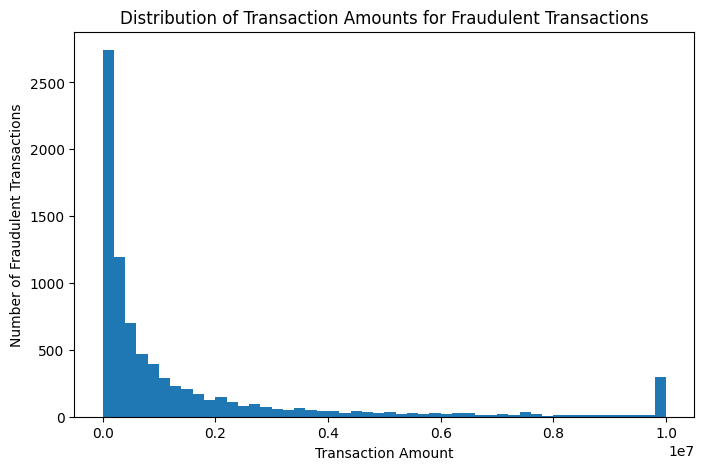

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(fraud_df["amount"], bins=50)

plt.title("Distribution of Transaction Amounts for Fraudulent Transactions")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Fraudulent Transactions")

plt.show()

In [15]:
fraud_df[["oldbalanceOrg", "newbalanceOrig"]].describe()

,oldbalanceOrg,newbalanceOrig
count,8.213000e+03,8.213000e+03
mean,1.649668e+06,1.923926e+05
std,3.547719e+06,1.965666e+06
min,0.000000e+00,0.000000e+00
25%,1.258224e+05,0.000000e+00
50%,4.389835e+05,0.000000e+00
75%,1.517771e+06,0.000000e+00
max,5.958504e+07,4.958504e+07


In [ ]:
## in the Fraud transactions:

-oldbalanceOrg average ≈ 1,649,668
-newbalanceOrig average ≈ 192,393
-newbalanceOrig median = 0

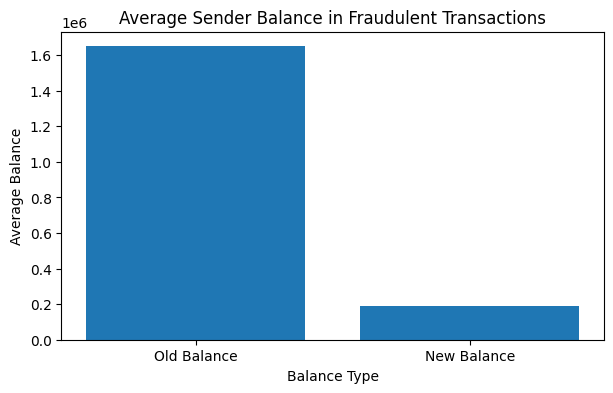

In [16]:
balance_means = fraud_df[["oldbalanceOrg", "newbalanceOrig"]].mean()

plt.figure(figsize=(7, 4))
plt.bar(
    ["Old Balance", "New Balance"],
    balance_means.values
)

plt.title("Average Sender Balance in Fraudulent Transactions")
plt.xlabel("Balance Type")
plt.ylabel("Average Balance")
plt.show()

In [17]:
fraud_amount_by_type = fraud_df.groupby("type")["amount"].mean()

fraud_amount_by_type

type
CASH_OUT    1.455103e+06
TRANSFER    1.480892e+06
Name: amount, dtype: float64

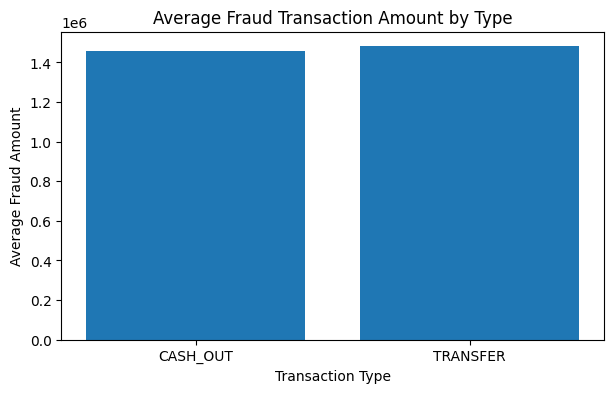

In [18]:
plt.figure(figsize=(7, 4))

plt.bar(
    fraud_amount_by_type.index,
    fraud_amount_by_type.values
)

plt.title("Average Fraud Transaction Amount by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Average Fraud Amount")
plt.show()

In [19]:
fraud_by_step = fraud_df.groupby("step").size()

fraud_by_step.head(20)

step
1     16
2      8
3      4
4     10
5      6
6     22
7     12
8     12
9     19
10    11
11     7
12    14
13    14
14    12
15    20
16    10
17     7
18    16
19    11
20     4
dtype: int64

In [20]:
fraud_by_step.sort_values(ascending=False).head(10)

step
212    40
523    30
501    28
387    28
249    28
425    28
730    28
160    26
398    26
694    24
dtype: int64

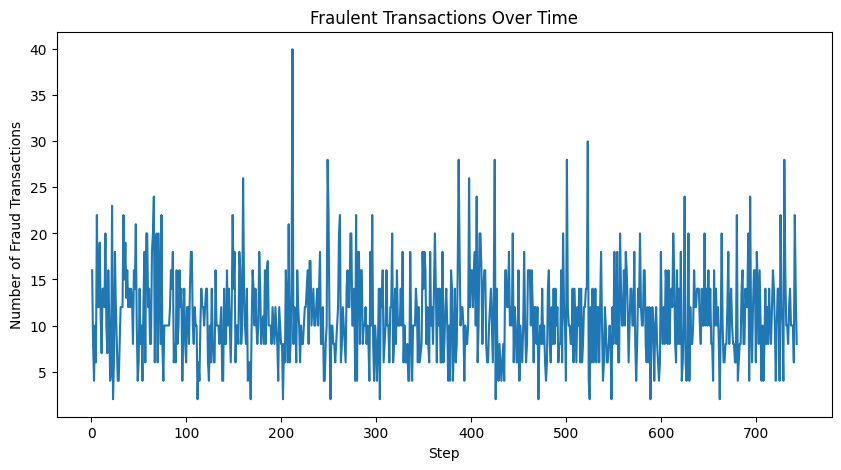

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(fraud_by_step.index, fraud_by_step.values)

plt.title("Fraulent Transactions Over Time")
plt.xlabel("Step")
plt.ylabel("Number of Fraud Transactions")

plt.show()

In [22]:
fraud_rate_by_type = df.groupby("type")["isFraud"].mean() * 100

fraud_rate_by_type

type
CASH_IN     0.000000
CASH_OUT    0.183955
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.768799
Name: isFraud, dtype: float64

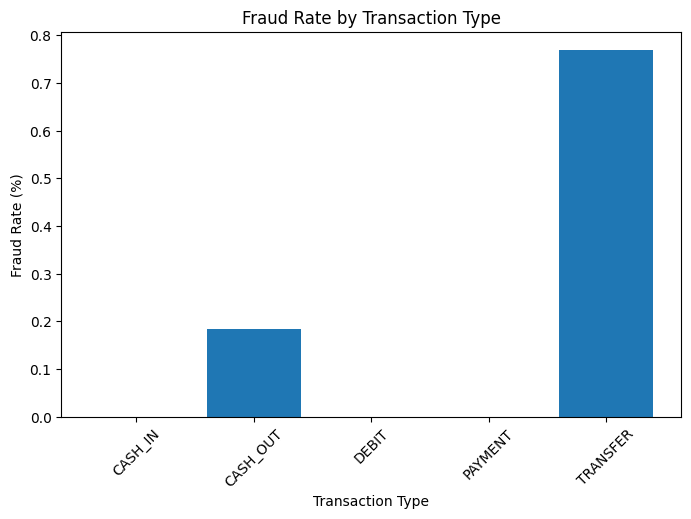

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    fraud_rate_by_type.index,
    fraud_rate_by_type.values
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [24]:
fraud_df["balance_change"] = (
    fraud_df["oldbalanceOrg"] - fraud_df["newbalanceOrig"]
)

fraud_df["balance_change"].describe()

count    8.213000e+03
mean     1.457275e+06
std      2.396099e+06
min      0.000000e+00
25%      1.245826e+05
50%      4.363175e+05
75%      1.503035e+06
max      1.000000e+07
Name: balance_change, dtype: float64

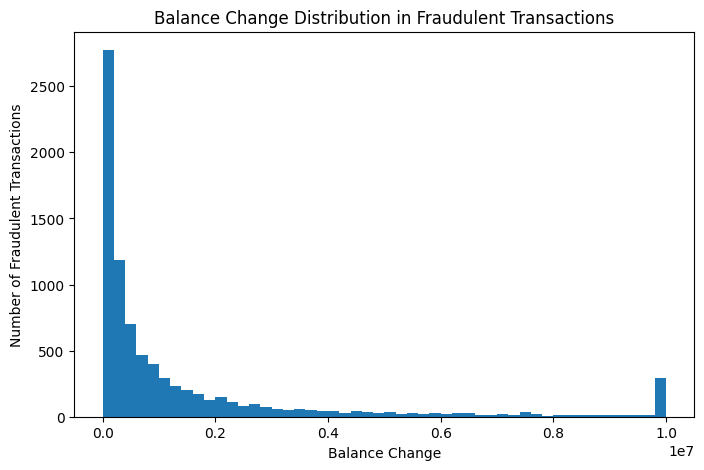

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(fraud_df["balance_change"], bins=50)

plt.title("Balance Change Distribution in Fraudulent Transactions")
plt.xlabel("Balance Change")
plt.ylabel("Number of Fraudulent Transactions")

plt.show()

In [26]:
fraud_df[["oldbalanceDest", "newbalanceDest"]].describe()

,oldbalanceDest,newbalanceDest
count,8.213000e+03,8.213000e+03
mean,5.442496e+05,1.279708e+06
std,3.336421e+06,3.908817e+06
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,4.676420e+03
75%,1.478287e+05,1.058725e+06
max,2.362305e+08,2.367265e+08


In [ ]:
#Fraud transactions:

oldbalanceDest average ≈ 544,250
newbalanceDest average ≈ 1,279,708
oldbalanceDest median = 0
newbalanceDest median ≈ 4,676

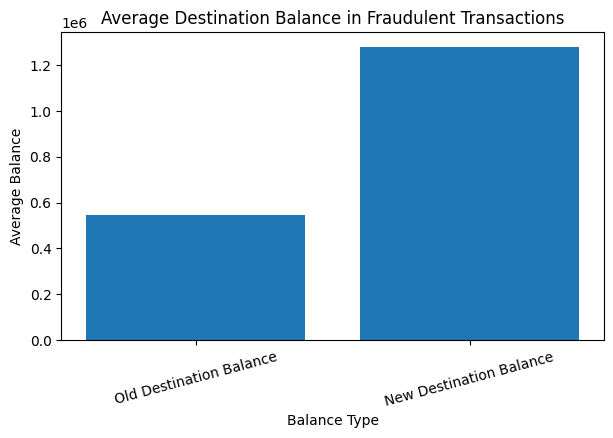

In [27]:
dest_balance_means = fraud_df[["oldbalanceDest", "newbalanceDest"]].mean()

plt.figure(figsize=(7, 4))

plt.bar(
    ["Old Destination Balance", "New Destination Balance"],
    dest_balance_means.values
)

plt.title("Average Destination Balance in Fraudulent Transactions")
plt.xlabel("Balance Type")
plt.ylabel("Average Balance")
plt.xticks(rotation=15)

plt.show()

# Week 2: Key Findings

## Exploratory Data Analysis Summary

1. The dataset is highly imbalanced, with 8,213 fraudulent transactions compared with 6,354,407 non-fraudulent transactions.

2. Fraudulent transactions were observed only in CASH_OUT and TRANSFER transaction types.

3. TRANSFER transactions had the highest fraud rate at approximately 0.769%, followed by CASH_OUT at approximately 0.184%.

4. The average transaction amount for fraudulent transactions was approximately 1.47 million, compared with approximately 0.178 million for non-fraudulent transactions.

5. Fraudulent transactions showed significant changes in sender balances between the original and new balances.

6. Fraudulent transactions also showed noticeable changes in destination balances.

7. Fraud occurrences varied across different time steps, with step 212 having the highest observed fraud count among the steps analyzed.

## Conclusion

The EDA indicates that transaction type, transaction amount, balance changes, and transaction timing are important patterns associated with fraudulent transactions. These findings can be used in the next stages of the project for feature engineering and machine learning.